---
embed-resources: True
format:
    html:
        page-layout: full
        grid:
            body_width: 1200px
        fontsize: 18px

title: 'Trabajo Práctico N° 2'
author: 'Lorenzo Marquesini'
warning: False
toc: False
---

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Lectura de datos

Los datos fueron 10M de filas generadas artificialmente de forma uniforme.

In [ ]:
ventas_csv = pd.read_csv("../00_DATA/ventas.csv") # Lectura

Guardamos como parquet

In [ ]:
ventas_csv.to_parquet("../00_DATA/ventas.parquet")
del ventas_csv # Libero memoria eliminando ventas_csv

## Lectura con parquet

In [7]:
ventas_parquet = pd.read_parquet("../00_DATA/ventas.parquet")

In [8]:
ventas_parquet.head()

,fecha,producto,categoria,cantidad,precio_unitario,región
0,2025-01-01,remera-algodon,calzado-mujer,14,37,Oeste
1,2025-01-01,chaqueta-algodon,outdoor-basico,8,79,Sur
2,2025-01-01,short-urbano,deporte-infantil,14,49,Norte
3,2025-01-01,gorro-urbano,calzado-infantil,8,87,Oeste
4,2025-01-01,short-algodon,accesorio-mujer,4,83,Norte


### Análisis Básico

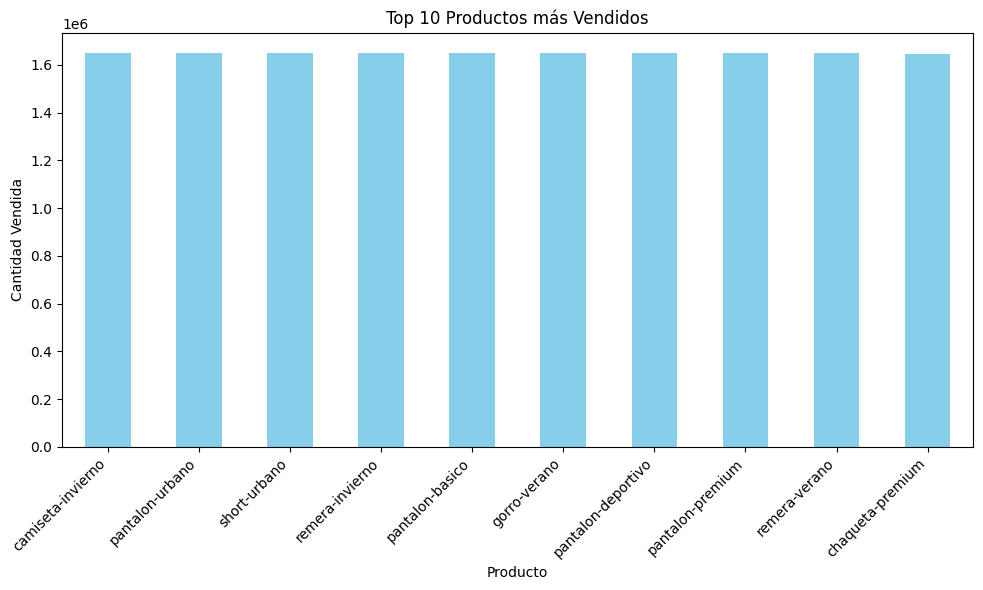

In [11]:
# Seleccionamos los 10 productos más vendidos
top_productos = ventas_parquet.groupby('producto')['cantidad'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_productos.plot(kind='bar', color='skyblue')
plt.title('Top 10 Productos más Vendidos')
plt.xlabel('Producto')
plt.ylabel('Cantidad Vendida')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

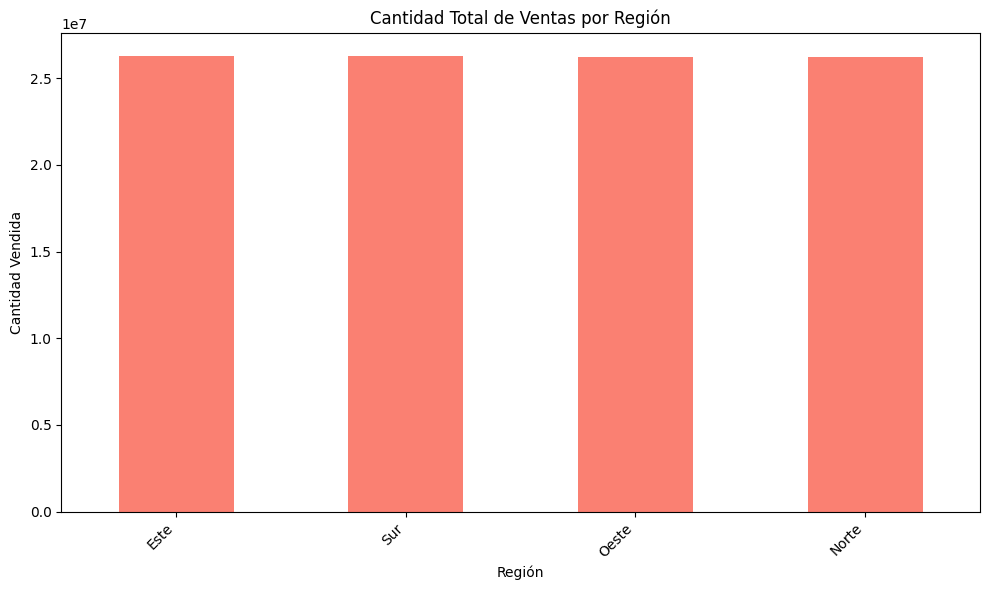

In [12]:
# Cantidad de ventas por región
ventas_por_region = ventas_parquet.groupby('región')['cantidad'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
ventas_por_region.plot(kind='bar', color='salmon')
plt.title('Cantidad Total de Ventas por Región')
plt.xlabel('Región')
plt.ylabel('Cantidad Vendida')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

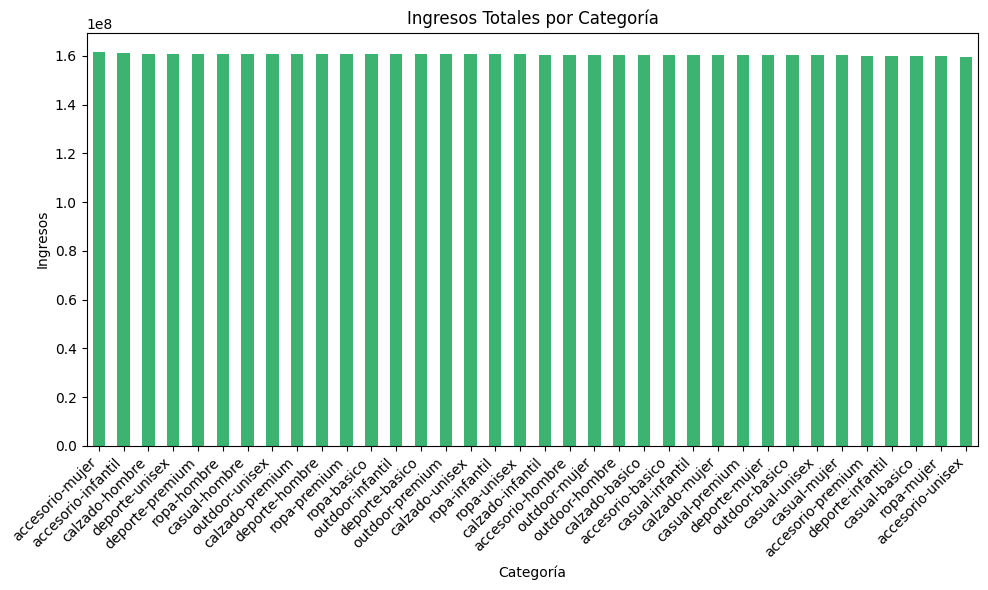

In [13]:
# Ingresos por categoría
ventas_por_categoria = ventas_parquet.groupby('categoria').apply(lambda x: (x['cantidad'] * x['precio_unitario']).sum()).sort_values(ascending=False)

plt.figure(figsize=(10,6))
ventas_por_categoria.plot(kind='bar', color='mediumseagreen')
plt.title('Ingresos Totales por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ingresos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Resumen de resultados

In [19]:
top_productos.head()

producto
camiseta-invierno    1651815
pantalon-urbano      1651433
short-urbano         1650373
remera-invierno      1649459
pantalon-basico      1648864
Name: cantidad, dtype: int64

In [18]:
ventas_por_region.head()

región
Este     26296578
Sur      26267017
Oeste    26237486
Norte    26234163
Name: cantidad, dtype: int64

In [17]:
ventas_por_categoria.head()

categoria
accesorio-mujer       161361658
accesorio-infantil    161240805
calzado-hombre        160947927
deporte-unisex        160931139
deporte-premium       160923075
dtype: int64

### Guardamos los resumenes en parquet

In [20]:
import pyarrow as pa
import pyarrow.parquet as pq

# Diccionario de resultados y nombres de archivo
resultados = {
    'top_productos': top_productos,
    'ventas_por_region': ventas_por_region,
    'ventas_por_categoria': ventas_por_categoria
}

for nombre, resultado in resultados.items():
    # Convierte Series a DataFrame antes de guardar si es necesario
    if isinstance(resultado, pd.Series):
        resultado_df = resultado.reset_index()
    else:
        resultado_df = resultado

    resultado_df.to_parquet(f'{nombre}.parquet', index=False)